<a href="https://colab.research.google.com/github/Tuhin092005/Project_3_Online_Payment_Fraud_Detection_System_Using_Machine_Learning/blob/main/Online_Payment_Fraud_Detection_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import required libraries

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

In [2]:
# Load the dataset

df = pd.read_csv("Online_Payment_Fraud_Dataset.csv")

In [3]:
# Preview / Display the dataset

df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,382,CASH_OUT,283639,C786579303,164329,24578,C826517607,739126,620632,1,1
1,579,TRANSFER,232077,C219540831,213933,254927,C683246764,269578,44258,1,0
2,186,DEBIT,91388,C126855092,22076,332346,C507693523,328624,548892,0,0
3,346,PAYMENT,111066,C896233790,207028,232459,M523625992,54604,489114,0,0
4,238,TRANSFER,107541,C395310485,339205,301614,C978726109,629443,120384,0,0


In [4]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   step            3000 non-null   int64 
 1   type            3000 non-null   object
 2   amount          3000 non-null   int64 
 3   nameOrig        3000 non-null   object
 4   oldbalanceOrg   3000 non-null   int64 
 5   newbalanceOrig  3000 non-null   int64 
 6   nameDest        3000 non-null   object
 7   oldbalanceDest  3000 non-null   int64 
 8   newbalanceDest  3000 non-null   int64 
 9   isFraud         3000 non-null   int64 
 10  isFlaggedFraud  3000 non-null   int64 
dtypes: int64(8), object(3)
memory usage: 257.9+ KB


In [5]:
# Check number of rows and columns

df.shape

(3000, 11)

In [6]:
# Display statistical summary

df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,350.890000,151817.344667,251837.492000,246866.274667,402788.761000,396611.889000,0.229333,0.053667
std,204.355952,86792.263722,143904.354525,143182.457492,232831.037433,229754.625628,0.420474,0.225396
min,1.000000,174.000000,37.000000,15.000000,5.000000,615.000000,0.000000,0.000000
25%,170.000000,78568.500000,127990.250000,122029.250000,199487.000000,198549.750000,0.000000,0.000000
50%,350.000000,151676.500000,254660.500000,249058.500000,409403.500000,398092.000000,0.000000,0.000000
75%,526.000000,228756.000000,375523.500000,366942.250000,604085.250000,597098.000000,0.000000,0.000000
max,699.000000,299999.000000,499964.000000,499920.000000,799947.000000,799800.000000,1.000000,1.000000


In [7]:
# Check and handle missing values

df.isnull().sum()

df.fillna(df.mean(numeric_only=True), inplace=True)

In [8]:
# Check and handle duplicate rows

df.duplicated().sum()

df.drop_duplicates(inplace=True)

In [9]:
# Check target column

df['isFraud'].value_counts()

,count
isFraud,
0,2312
1,688


In [10]:
# Remove unnecessary ID columns

df = df.drop(["nameOrig", "nameDest"], axis=1, errors="ignore")

In [11]:
# Separate features and target

X = df.drop(['isFraud',], axis=1)

y = df['isFraud']

In [12]:
# Encode categorical data

categorical_columns = X.select_dtypes(include='object').columns

label_encoders = {}

for column in categorical_columns:
    encoder = LabelEncoder()
    X[column] = encoder.fit_transform(X[column])
    label_encoders[column] = encoder

In [13]:
# Feature scaling

feature_names = X.columns

scaler = StandardScaler()

X = scaler.fit_transform(X)

In [14]:
# Split the dataset

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
# Train Logistic Regression model

lr = LogisticRegression(
    max_iter=10,
    random_state=42
)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

lr_accuracy = accuracy_score(y_test, y_pred_lr)

print(f"Accuracy of the Logistic Regression: {lr_accuracy * 100:.2f}%")

Accuracy of the Logistic Regression: 78.33%


In [16]:
# Train Decision Tree model

dt = DecisionTreeClassifier(
    max_depth=15,
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)

print(f"Accuracy of the Decision Tree Classifier: {dt_accuracy * 100:.2f}%")

Accuracy of the Decision Tree Classifier: 93.50%


In [17]:
# Train Random Forest model

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print(f"Accuracy of the Random Forest Classifier: {rf_accuracy * 100:.2f}%")

Accuracy of the Random Forest Classifier: 96.50%


In [18]:
# Compare all Models

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree Classifier",
        "Random Forest Classifier"
    ],

    "Accuracy(%)": [
        lr_accuracy * 100,
        dt_accuracy * 100,
        rf_accuracy * 100
    ]
})

model_comparison

,Model,Accuracy(%)
0,Logistic Regression,78.333333
1,Decision Tree Classifier,93.500000
2,Random Forest Classifier,96.500000


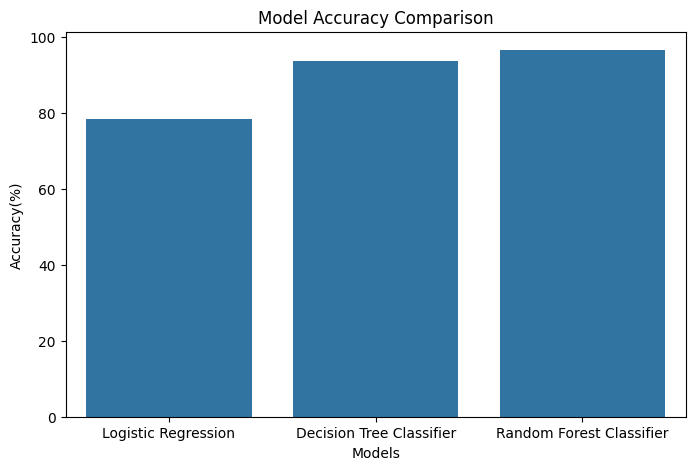

In [19]:
# Plot accuracy graph

plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="Accuracy(%)",
    data=model_comparison
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy(%)")

plt.show()

In [20]:
# Find the best model

best_model_name = model_comparison.loc[
    model_comparison["Accuracy(%)"].idxmax(),
    "Model"
]

print("Best Model:", best_model_name)

Best Model: Random Forest Classifier


In [21]:
# Select the actual trained model

if best_model_name == "Logistic Regression":
    best_model = lr

elif best_model_name == "Decision Tree Classifier":
    best_model = dt

elif best_model_name == "Random Forest Classifier":
    best_model = rf

In [22]:
# Creating Confusion Matrix

y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

print(cm)

[[473   0]
 [ 21 106]]


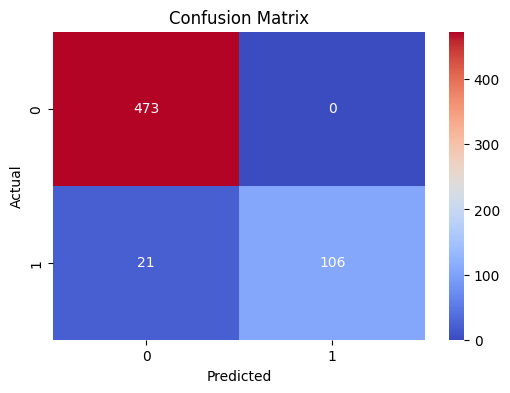

In [23]:
# Plotting Confusion Matrix

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='coolwarm'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [24]:
# Display classification report

print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       473
           1       1.00      0.83      0.91       127

    accuracy                           0.96       600
   macro avg       0.98      0.92      0.94       600
weighted avg       0.97      0.96      0.96       600



In [25]:
# Calculate feature importance

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_model.feature_importances_
})

In [26]:
# Sort feature importance

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
1,type,0.331508
2,amount,0.313664
3,oldbalanceOrg,0.142603
5,oldbalanceDest,0.055703
4,newbalanceOrig,0.053630
0,step,0.050755
6,newbalanceDest,0.048734
7,isFlaggedFraud,0.003403


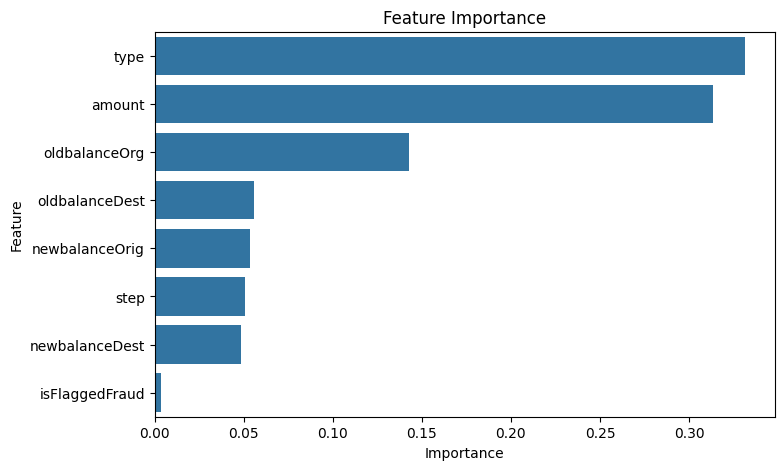

In [27]:
# Plot feature importance

plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)

plt.title("Feature Importance")

plt.show()

In [28]:
# Function for fraud prediction

def predict_fraud(input_data):
  input_df = pd.DataFrame(
      [input_data],
      columns=feature_names
  )

  input_df['type'] = encoder.transform(input_df['type'])

  input_scaled = scaler.transform(input_df)

  prediction = best_model.predict(input_scaled)

  return prediction[0]

In [29]:
# Create new data

new_data = {
    'step': 600,
    'type': 'TRANSFER',
    'amount': 950000,
    'oldbalanceOrg': 950000,
    'newbalanceOrig': 0,
    'oldbalanceDest': 0,
    'newbalanceDest': 950000,
    'isFlaggedFraud': 0
}

In [30]:
# Predict fraud risk

result = predict_fraud(new_data)

print("Prediction:", result)

Prediction: 1


In [31]:
# Display transaction result

if (result == 1):
    print("Transaction Status : Fraudulent Transaction")

else:
    print("Transaction Status : Legitimate Transaction")

Transaction Status : Fraudulent Transaction


In [32]:
# Create another new data

new_data1 = {
    'step': 250,
    'type': 'PAYMENT',
    'amount': 4500.75,
    'nameOrig': 'C123456789',
    'oldbalanceOrg': 15000.00,
    'newbalanceOrig': 10500.25,
    'nameDest': 'M987654321',
    'oldbalanceDest': 5000.00,
    'newbalanceDest': 9500.75
}

In [33]:
# Predict fraud risk

result1 = predict_fraud(new_data1)

print("Prediction:", result1)

Prediction: 0


In [34]:
# Display transaction result

if (result1 == 1):
    print("Transaction Status : Fraudulent Transaction")

else:
    print("Transaction Status : Legitimate Transaction")

Transaction Status : Legitimate Transaction


In [35]:
# Save ML files

joblib.dump(best_model, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(feature_names, "feature_names.pkl")
joblib.dump(label_encoders, "label_encoders.pkl")

print("All ML files saved successfully.")

All ML files saved successfully.
